# Week 6 - Logistic Regression

**Darren Lim**

### Aims

The main concepts covered in this notebook are:

>* logistic regression
>* performance metrics for classification
>* dealing with imbalanced data 
>* multi-class logistic regression

1. [Setup](#setup)

2. [Binary Logistic Regression](#RBH)

3. [Regularization](#SKV)

4. [Imbalanced Data](#Imbal)

5. [Multi-class Example](#mclog)


This week we will be implementing logistic regression for a classification task. 

- We will mainly focus on the data set stored in `Default.csv`.
- For the multi-class example, we consider the `iris data` at the end of the notebook.

During workshops, you will complete the worksheets together in teams of 2-3, using **pair programming**. You should aim to switch roles between driver and navigator approximately every 15 minutes. When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 
>- In some Exercises, you will see some beneficial hints at the bottom of questions.

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

---

# Setup <a id='setup'></a>

## Packages

Let's load the packages we need for this workshop.

In [2]:
# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
from sklearn.linear_model import LogisticRegression

# Other necessary packages
from sklearn.preprocessing import StandardScaler # scaling features
from sklearn.pipeline import make_pipeline           # combining classifier steps
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold 
from sklearn.model_selection import train_test_split

## Helper Functions

We will make use of one of the helper functions that we saw last week.

In [33]:
def get_coefs(m, plot = False, feature_names = None, figsize = (5,5), figtitle = None, intercept = True):
    """Returns model coefficients in a data frame for a fitted linear model.
    
    Args:
        m: sklearn linear model object or pipeline with linear model as final step
        plot: boolean value, should coefficients be plotted with error bars
        feature_names: list of feature names to use in the plot 
        figsize: tuple defining figure size
        figtitle: string defining figure title
        intercept: boolean value, should intercept be included in the plot
    """
    
    # Extract intercept and coefficients into a single array
    w0 = m[-1].intercept_ if isinstance(m, sklearn.pipeline.Pipeline) else m.intercept_
    w1 = m[-1].coef_ if isinstance(m, sklearn.pipeline.Pipeline) else m.coef_
    w = np.concatenate((w0.reshape(-1), w1.reshape(-1)))
    # Extract name of features
    if feature_names is None:
        feature_names = m[:-1].get_feature_names_out() if isinstance(m, sklearn.pipeline.Pipeline) else m.feature_names_in_
    feature_names = np.concatenate((['intercept'], feature_names))
    # Create a data frame
    w_df = pd.DataFrame({'feature': feature_names, 'coef': w}).sort_values ("coef", ascending=False)

    if plot:
        if not intercept:
            w_df = w_df[w_df['feature'] != 'intercept']
        plt.figure(figsize=figsize)
        plt.barh(w_df['feature'], w_df['coef'])
        plt.ylabel('Features')
        plt.xlabel('Coefficient Value')
        plt.axvline(x=0, color=".5")
        if figtitle is not None:
            plt.title(figtitle)
        plt.grid()
        plt.show()
    
    return  w_df

## Data

The dataset collects information on **10000** individuals, recording whether they defaulted on their credit card or not as well as other characteristics. Specifically, the included columns in the data are:

* `default` - Whether the individual has defaulted

* `student` - Whether the individual is the student

* `balance` - The balance in the individual's account

* `income` - Income of an individual

Our aim is to build a model using Logistic Regression to predict if person will default or not.

In [4]:
df_default = pd.read_csv("Default.csv", index_col=0)

df_default.head()

,default,student,balance,income
1,No,No,729.526495,44361.62507
2,No,Yes,817.180407,12106.13470
3,No,No,1073.549164,31767.13895
4,No,No,529.250605,35704.49394
5,No,No,785.655883,38463.49588


## Exploratory Data Analysis

We will start with explanatory data analysis (EDA) to get more insight about the data. 

### 🚩 Exercise 1 (CORE)

Examine the structure of the data. Consider the following questions:

a. What are the types of each variable? Based on the descriptive statistics, do anticipate any feature engineering steps that may be needed? Are there any missing values in the data? 

b. Visualize the features (balance, income, student) and comment on any differences that you observe between individuals that have defaulted 

In [5]:
# Part a: info and descriptive statistics
print(df_default.info())
print(df_default.describe())



<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 390.6+ KB
None
            balance        income
count  10000.000000  10000.000000
mean     835.374886  33516.981876
std      483.714985  13336.639563
min        0.000000    771.967729
25%      481.731105  21340.462905
50%      823.636973  34552.644800
75%     1166.308387  43807.729275
max     2654.322576  73554.233500


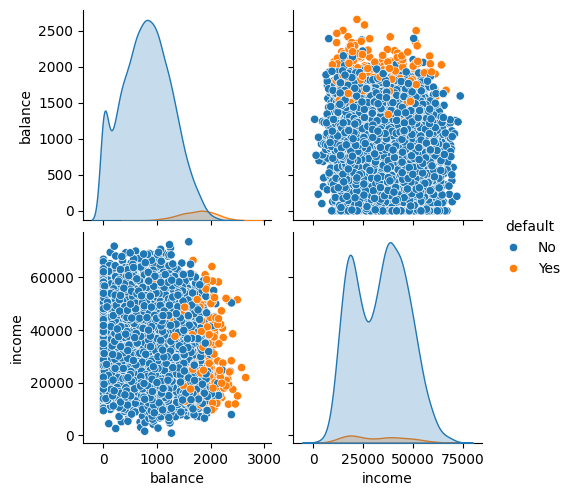

None

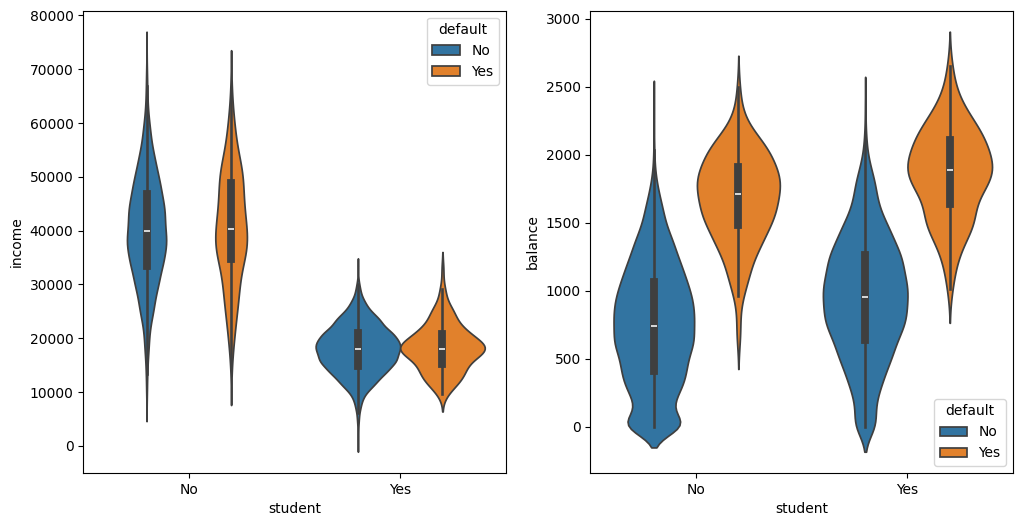

None

In [6]:
# Part b: Visualize the data
sns.pairplot(data = df_default, hue = "default", vars = ["balance", "income"])
display(plt.show())

fig, ax = plt.subplots(1, 2, figsize = (12, 6))
sns.violinplot(data = df_default, x = "student", y = "income", hue = "default", ax = ax[0])
sns.violinplot(data = df_default, x = "student", y = "balance", hue = "default", ax = ax[1])
display(plt.show())

Q1a)

- "default": Categorical with 2 categories ["Yes", "No"]
- "student": Categorical with 2 categories ["Yes, "No"]
- "income": Continuous
- "balance"" Continuous

- Have to feature-engineer the categorical variables by one-hot encoding. There seems to be no missing values.
- Since we are examining "default" as the output, the sample data seems very imbalanced, where there is a significantly greater proportion of people sampled who do not default than those who default. May need to alter the training algorithm or data.

Q1b)

- There seems to be a positive association between "balance" and "default". People who default tend to have higher balances in their accounts.
- "income" and "student" do not seem to have any clear association with "default"

## Splitting and Preprocessing the Data

Next, let's create our feature matrix and response vector. We use `LabelEncoder` to encode our categorical output to a binary vector. 

In [7]:
from sklearn.preprocessing import LabelEncoder

# Feature matrix and response vector
X, y = df_default.drop(['default'], axis=1), df_default['default']

# Encode default
y = LabelEncoder().fit_transform(y)

print(X.shape)
print(y.shape)

# Print the class distribution before splitting the data set 
print(pd.Series(y).value_counts(normalize=True)*100)

(10000, 3)
(10000,)
0    96.67
1     3.33
Name: proportion, dtype: float64


Notice the high class imbalance, with 96.67% of individuals that have not defaulted on their loan. Consider the following naive train/test split.

In [8]:
# Naively split the data into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle= True,
                                                    test_size = 0.1, random_state=1112)


# Check the proportion of defaults in both train and test data sets 
print(pd.Series(y_train).value_counts(normalize=True)*100)
print(pd.Series(y_test).value_counts(normalize=True)*100)

0    96.522222
1     3.477778
Name: proportion, dtype: float64
0    98.0
1     2.0
Name: proportion, dtype: float64


### 🚩 Exercise 2 (CORE)

a. Why might you NOT want to use the train/test split above?

b. Modify the code to have similar class proportions in the train and test sets. Print the class proportions to check if they are similar. 

**Hint:** consider the the additional argument `stratify=` inside of the [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function to stratify in terms of the response when spliting the data.

Q2a)

With only ~3.33% people who default, a random split could result in very different class proportions in the the train and test sets, in which either set may under- or over-represent the minority class.

This can lead to significantly different distributions between the train and test sets, leading to unreliable performance estimates.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=True, test_size=0.1, random_state=1112, stratify=y
)

# Check the proportion of defaults in both train and test data sets
print("Train class proportions:")
print(pd.Series(y_train).value_counts(normalize=True)*100)
print("\nTest class proportions:")
print(pd.Series(y_test).value_counts(normalize=True)*100)

Train class proportions:
0    96.666667
1     3.333333
Name: proportion, dtype: float64

Test class proportions:
0    96.7
1     3.3
Name: proportion, dtype: float64


# Logistic Regression <a id='RBH'></a>

Recall from our notes that for a binary output $y \in \lbrace 0, 1 \rbrace$, **logistic regression** is a classifier that can be seen a simple generalization of linear regression by making two changes. 

- First, we replaced the **Gaussian** distribution of the output $y$ with a **Bernoulli** distribution. 
- Second, we pass the linear function of the inputs, $\mathbf{w}^T\mathbf{x}$, through a **link function** $g: \mathbb{R} \rightarrow [0,1]$. 

That is, we assume $y \sim \text{Bern}( g(\mathbf{w}^T\mathbf{x}))$.

The link function takes values in the unit interval to ensure that the conditional probability of a success, 

$$p(y =1 \mid \mathbf{x}) = E[y | \mathbf{x}] = g(\mathbf{w}^T\mathbf{x})$$

is between zero and one. Specifically, in logistic regression, we select the **logistic** link function (S-shaped), defined as 

$$g(\mathbf{w}^T\mathbf{x}) = \frac{1}{1 + \exp(-\mathbf{w}^T\mathbf{x})}$$

Putting these steps together, the logistic regression model is:

$$y \sim \text{Bern}\left( \left[1 + \exp(-\mathbf{w}^T\mathbf{x})\right]^{-1} \right)$$

In `sklearn`, we can fit a logistic regression model using [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). 

**Creating a logistic regression model:** some important options include
- `penalty` specifies the type of regularization. Options are `l1`, `l2`, `elasticnet`, `None`. 
- `C` the inverse strength of the penalty parameter.
- 'l1_ratio' the additional penalty parameter when using `elasticnet`.

**CAUTION:** by default `LogisticRegression` uses an l2 regularization with penalty parameter `C=1`. This default should never be used! Instead, you should either set `penalty=None` or tune the value of `C` with cross-validation. 

**Fitting a logistic regression model:**
- use the usual `.fit(X,y)` to fit the model. The fitted object stores the intercept and coefficients in the usual attributes `.intercept_` and `.coef_`.

**Prediction:** methods include
- `predict` which predicts the class label (either 0 or 1), 
- `predict_proba` which predicts the class probabilities, and 
- `predict_log_proba` which predicts the log probabilities of each class.

Let's start by create a pipeline to for our logisitic regression model (with no penatly).

In [10]:
# Pipeline
log_pipe = make_pipeline(
    ColumnTransformer(
        [("cat", OneHotEncoder(drop=["No"]), ['student']),
         ("num", StandardScaler(), ['balance','income'])],
         verbose_feature_names_out=False
    ),
    LogisticRegression(random_state=42, penalty=None)
)

### 🚩 Exercise 3 (CORE)

- Fit the logistic regression model to the training data
- Plot the coefficients using the helper function and comment on their interpretation.
- Compute the the accuracy score of the model on the testing data

<details><summary><b><u>Hint</b></u></summary>
    
You can use the `score` method of `LogisiticRegression` to compute the accuracy.
    
</details>


Test Accuracy: 0.9750


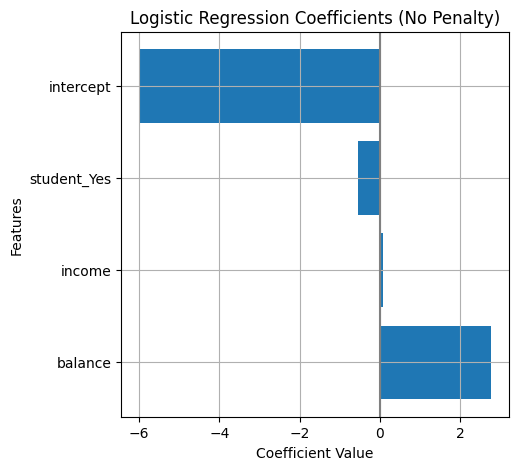

       feature      coef
2      balance  2.773691
3       income  0.070656
1  student_Yes -0.553895
0    intercept -5.999642


In [13]:
import sklearn

# Fit the model using the training data
log_pipe.fit(X_train, y_train)

# Compute accuracy on the test data (see hint)
acc = log_pipe.score(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

# Plot the coefficients using the helper function
coef_df = get_coefs(log_pipe, plot=True, figtitle='Logistic Regression Coefficients (No Penalty)')
print(coef_df)

Q3)

- "balance" has the largest positive coefficient of ~2.77, which means one standard deviation increase in balance is associated with a much higher log-odds of defaulting. Most important predictor.
- "income" has a small positive coefficient of ~0.07, which means minimal effect on default probability.
- "student_yes" has a negative coefficient of ~-0.55, which means being a student is associated with a lower log-odds of defaulting.
- "intercept" is strongly negative at ~-6.00, which shows that at the base rate, most individuals do not default.

While test accuracy is high at 97.5%, this may be misleading due to imbalanced data.

## Evaluating Classification Models: Beyond Accuracy

Because of the imbalanced nature of the data, looking at accuracy alone is misleading. Indeed, a naive classifier that predicts no one defaults would achieve a high accuracy of 96.7%.  

A binary classifier can make two types of errors:

- Incorrectly assigning an individual __who defaults__ to the __no default__ category (FN)
- Incorrectly assigning an individual who __does not default__ to the __default__ category (FP)

To better understand the FN vs FP tradeoff, we can compute the confusion matrix. Recall from our notes, the quantities reported in the confusion matrix are:


$$\text{TP} = \sum_{n=1}^N \mathbb{I}(y_n=1)\mathbb{I}(\widehat{y}_n=1),\quad \text{FP} = \sum_{n=1}^N \mathbb{I}(y_n=0)\mathbb{I}(\widehat{y}_n=1)$$
$$\text{FN} = \sum_{n=1}^N \mathbb{I}(y_n=1)\mathbb{I}(\widehat{y}_n=0), \quad \text{TN} = \sum_{n=1}^N \mathbb{I}(y_n=0)\mathbb{I}(\widehat{y}_n=0)$$


where $y_n$ is the true class and $\widehat{y}_n$ is the estimated class. 

### 🚩 Exercise 4 (CORE)

1. Use [ConfusionMatrixDisplay.from_estimator](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_estimator) to compute and visualize the confusion matrix. 
2. Comment on the importance of FNs compared to FPs to the credit card company.

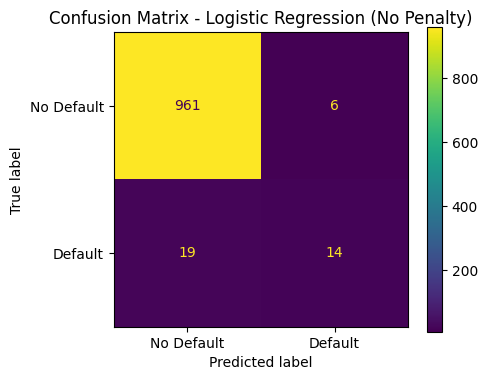

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(
    log_pipe, X_test, y_test,
    display_labels=['No Default', 'Default'],
    ax=ax
)
plt.title('Confusion Matrix - Logistic Regression (No Penalty)')
plt.tight_layout()
plt.show()

Q4)

- False Negative (FN) = Predicted "No Default" but person actually defaults.
- False Positive (FP) = Predicted "Default" but person does not default.

To a credit card company, FNs are more important than FPs, as the company will lose money by mistakenly extending credit to people who do not repay, resulting in high financial loss.

Recall from our notes, the different evaluation measures can be defined from the confusion matrix, such as:

$$
\text{Accuracy} = \frac{\text{TP + TN}}{\text{TP + TN + FP + FN}}
$$

$$
\text{FPR} = \frac{\text{FP}}{\text{FP}+ \text{TN}}, \hspace{0.5cm} \text{Recall (TPR)} = \frac{\text{TP}}{\text{TP}+ \text{FN}} \hspace{0.5cm}
\text{Precision} = \frac{\text{TP}}{\text{TP}+ \text{FP}}
$$


$$
\text{F1-Score} = 2\left(\frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}\right) = \frac{\text{2TP}}{\text{2TP + FP + FN}}
$$

To compute these quantites and more, functions are available in `sklearn.metrics`, including:

1. [Recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) (True Positive Rate)
3. [Precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
4. [F1-score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
5. [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)

For a detailed list, see https://scikit-learn.org/1.5/modules/model_evaluation.html#classification-metrics.

### 🚩 Exercise 5 (CORE)

Compute the accuracy, recall, precision, and F1-score on the test data for the fitted model (using the functions in `sklearn.metrics`) and comment on the model's performance.

**Hint** you first need to use `.predict()` to predict the class labels.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

y_pred = log_pipe.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.9750
Recall: 0.4242
Precision: 0.7000
F1-score: 0.5283


Q5)

- 0.975 accuracy is high but misleading, due to imbalanced data.
- 0.424 recall means that the model identifies 42.4% of true defaulters, which is very problematic for the credit card company.
- 0.700 precision means when the model predicts a positive "default", it is correct 70.0% of the time, which may not be precise enough. This is also due to the significantly small proportion of defaulters in the data.
- 0.528 F1-score confirms poor performance on the minority class, that is, people who default.

Therefore, the model is heavily biased towards the majority class, that is, people who do not default.


### 🚩 Exercise 6 (EXTRA)

Based on the confusion matrix computed below. Use the equations above to derive:

1. False Positive Rate 
2. Recall
3. Precision
4. F1-score

without using any additional built-in function from any module. If computed correctly, the numbers should match the previous exercise.

In [17]:
from sklearn.metrics import confusion_matrix

# Predict class labels
y_test_pred = log_pipe.predict(X_test)

# Compute confusion matrix
confmat = confusion_matrix(y_true = y_test, y_pred=y_test_pred)
confmat

array([[961,   6],
       [ 19,  14]])

In [19]:
# Derive metrics manually from confusion matrix
TN, FP, FN, TP = confmat.ravel()
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")

FPR = FP / (FP + TN)
recall = TP / (TP + FN)
precision = TP / (TP + FP)
f1 = 2 * precision * recall / (precision + recall)

print(f"\nFalse Positive Rate: {FPR:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

TN=961, FP=6, FN=19, TP=14

False Positive Rate: 0.0062
Recall: 0.4242
Precision: 0.7000
F1-score: 0.5283


### 🚩 Exercise 7 (CORE)

The handy function `RocCurveDisplay.from_estimator` is also available in `sklearn` for plotting  ROC curve for the fitted model. Use this function to plot the ROC curve and compute the AUC using `sklearn.metrics.roc_auc_score` on the test data. Comment on the model's performance based on these quantities.

**Hint** you will need to use `predict_proba()` to compute the class probabilities for each data point, in order to compute the AUC.

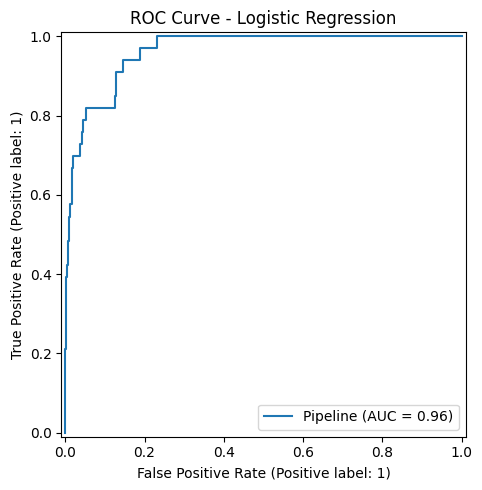

AUC: 0.9618


In [20]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_estimator(log_pipe, X_test, y_test, ax=ax)
plt.title('ROC Curve - Logistic Regression')
plt.tight_layout()
plt.show()

y_proba = log_pipe.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.4f}")


Q7)

- AUC of 0.962 indicates excellent discriminative ability, where the model ranks a random defaulter above a random non-defaulter 96.2% of the time.
- However, this AUC may be inflated by the imbalanced data, in which the majority class significantly dominates. Furthermore, the default threshold of 0.5 is inappropriate for imbalanced data.

### 🚩 Exercise 8 (CORE)

Now, use the function `PrecisionRecallDisplay.from_estimator` to plot the Precision-Recall curve for the fitted model on the test data. Comment on the model's performance based on this figure.

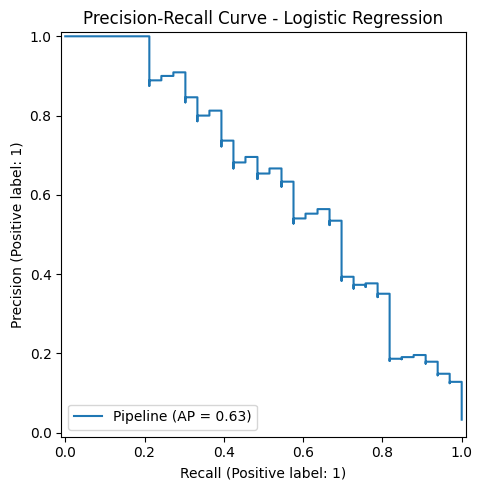

In [21]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6,5))
PrecisionRecallDisplay.from_estimator(log_pipe, X_test, y_test, ax=ax)
plt.title('Precision-Recall Curve - Logistic Regression')
plt.tight_layout()
plt.show()

Q8)

- At the default operating point, recall = 0.424 while precision = 0.700. While precision may be decent, recall is poor which is problematic for the company.
- Hence, a lower decision threshold than 0.5 would be appropriate to increase recall (catch more defaults), but decrease precision (more false positives). Hence, there is a need to determine the optimal precision-recall trade-off.

# Regularization <a id='SKV'></a>

Regularization can be useful in logistic regression to deal with high-dimensional data and for variable selection. As previous stated `LogisiticRegression` offers four options through the 'penalty' parameter:
- `penalty=None` corresponds to no regularization,
- `penalty=l2` is the default and corresponds to l2 regularization (ridge),
- `penalty=l1` corresponds to l1 regularization (lasso), and
- `penalty=elasticnet` corresponds to a combination of l1 and l2 regularizaiton.

For the three regularization methods, the parameter `C` represents the inverse strength of the penalty parameter. Additionaly, when using `elasticnet`, `l1_ratio` is an additional penalty parameter, controlling the balance between l1 and l2 regularization.

Note: the choice of the algorithm (aka solver) depends on the penalty chosen (see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for more details.)

As we saw last week, it is important to tune the penalty parameter `C` (and `l1_ratio` if using elastic net) when including regularization. Before we start searching over hyperparameters, its worth noting that some of the folds may not have the same distribution of the classes. This is particulary important for imbalanced data and means the we could get a validation score that may be a poor estimate of performance (for example we may have a fold with very few positive classes or more than usual, which can cause large differences on imbalanced data). To address this,  when doing our grid search, we will use a `StratifiedKFold` to ensure the distribution of classes in our folds reflects the distribution in the larger data.

Run the code below to investigate the difference in class distributions across folds when using `Kfold` vs `StratifiedKfold`.


In [24]:
# Consider 5 folds
KF = KFold(n_splits=5)
SKF = StratifiedKFold(n_splits=5)

fold_names = ["KFold", "StratifiedKFold"]
for i, K in enumerate([KF, SKF]):
    # Initialize an empty DataFrame to store counts for the current fold type
    fold_nos = pd.DataFrame()
    for j, (train_i, test_i) in enumerate(K.split(X_train, y_train)):
        # Compute value counts for the current fold and ensure it's a DataFrame with appropriate columns
        fold_no = pd.DataFrame(pd.Series(y_train[test_i]).value_counts()).T
        fold_no.index = ["Fold " + str(j)]  # Rename the index to reflect the fold number
        # Concatenate with the fold_nos DataFrame
        fold_nos = pd.concat([fold_nos, fold_no], axis=0)
    
    fold_nos.fillna(0, inplace=True)  # Fill missing values with 0 if any class was not present in a fold
    print(f"{fold_names[i]} counts per fold:\n", fold_nos)

KFold counts per fold:
            0   1
Fold 0  1744  56
Fold 1  1730  70
Fold 2  1746  54
Fold 3  1742  58
Fold 4  1738  62
StratifiedKFold counts per fold:
            0   1
Fold 0  1740  60
Fold 1  1740  60
Fold 2  1740  60
Fold 3  1740  60
Fold 4  1740  60


Next, let's perform a grid search to tune the regularization parameter with l2 regularization. Notice that we have listed multiple metrics to save with the option `scoring=`. However, setting `refit=` will select the best model and refit according to the  specfied metric.

In [25]:
# This code snippet sets up and executes a grid search for tuning the penalty parameter
# of a logistic regression model with l2 regularization using cross-validation. 

# Pipeline 
log_pipe_l2 = make_pipeline(
    ColumnTransformer(
        [("cat", OneHotEncoder(drop=["No"]), ['student']),
         ("num", StandardScaler(), ['balance','income'])],
         verbose_feature_names_out=False
    ),
    LogisticRegression(random_state=42, penalty='l2')
)

# Uncomment this line to find how the penalty parameter is called in the pipeline
#log_pipe.get_params()

# Possible C values: 
C_list = np.linspace(0.01, 10, num=151)


# Grid search CV:
log_rs = GridSearchCV(log_pipe_l2, 
                      param_grid={'logisticregression__C': C_list},
                      scoring = ["accuracy", "f1","recall","precision"], #Evaluation metrics to compute on validation sets
                      cv = StratifiedKFold(n_splits=5, shuffle=True),
                      refit = "accuracy", # Refits the best model on the entire dataset using the accuracy metric 
                      return_train_score = True)

# Tune the model with grid search:
log_rs.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'logisticregression__C': array([ 0.01 ...334, 10. ])}"
,scoring,"['accuracy', 'f1', ...]"
,n_jobs,None
,refit,'accuracy'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('cat', ...), ('num', ...)]"


### 🚩 Exercise 9 (CORE)

a. Run the following code to plot the mean accuracy averaged across the validation folds (in black). Comment on the suggested value of `C`.

b. Choose a metric other than accuracy (i.e. f1, recall, or precision) and redraw the figure to plot the mean across the validation folds. Does your suggested value of `C` change?

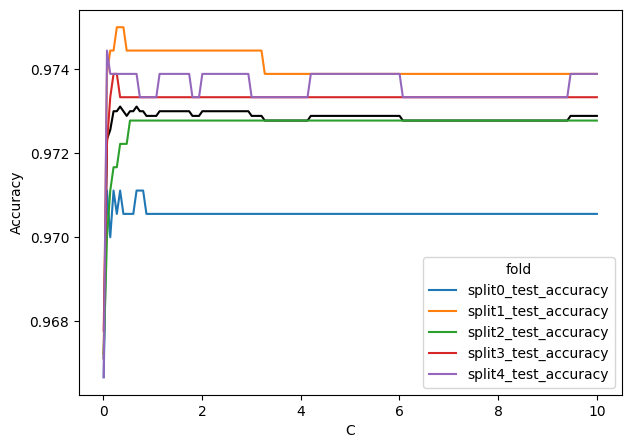

In [26]:
# Extract only mean and split scores
cv_accuracy = pd.DataFrame(
    data = log_rs.cv_results_
).filter(
    # Extract the split#_test_accuracy and mean_test_accuracy columns
    regex = '(split[0-4]+|mean)_test_accuracy'
).assign(
    # Add the alphas as a column
    C = C_list
)

# Reshape the data frame for plotting
d = cv_accuracy.melt(
    id_vars=('C','mean_test_accuracy'),
    var_name='fold',
    value_name='Accuracy'
)

# Plot the validation scores across folds
plt.figure(figsize=(7,5))
sns.lineplot(x='C', y='Accuracy', color='black', errorbar=None, data = d)  # Plot the mean score in black.
sns.lineplot(x='C', y='Accuracy', hue='fold', data = d) # Plot the curves for each fold in different colors
plt.show()

Q9a)

From the plot, mean CV accuracy stabilises very quickly at around C = ~0.5 and remains high across the full range (since the majority class dominates). However, the best C by accuracy is ~0.5, but the plateau suggests L2 regularization is not causing meaningful overfitting here.

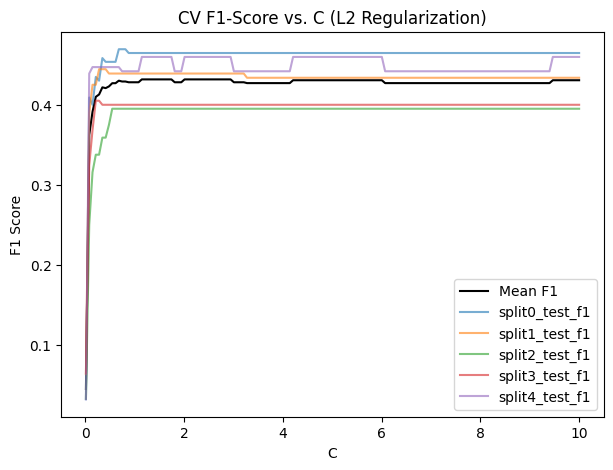

Best C by F1: 1.1422


In [27]:
cv_f1 = pd.DataFrame(data=log_rs.cv_results_).filter(
    regex='(split[0-4]+|mean)_test_f1'
).assign(C=C_list)

d_f1 = cv_f1.melt(
    id_vars=('C', 'mean_test_f1'),
    var_name='fold',
    value_name='F1'
)

plt.figure(figsize=(7,5))
sns.lineplot(x='C', y='mean_test_f1', color='black', errorbar=None, data=cv_f1, label='Mean F1')
sns.lineplot(x='C', y='F1', hue='fold', data=d_f1, alpha=0.6)
plt.xlabel('C')
plt.ylabel('F1 Score')
plt.title('CV F1-Score vs. C (L2 Regularization)')
plt.legend()
plt.show()

best_c_f1 = C_list[np.argmax(log_rs.cv_results_['mean_test_f1'])]
print(f"Best C by F1: {best_c_f1:.4f}")



Q9b)

Using F1-score as the metric, the suggested C changes significantly from ~0.5 to ~1.14.

### 🚩 Exercise 10 (EXTRA)

a. Rebuild your model with `l1` regularization and perform a grid search to tune the penalty parameter. Which metric have you chosen for refitting the model and why?

b. Plot the coefficients using the helper function. Which variables are included? How does the performance compare to the model with no regularization?

Best C (L1): {'logisticregression__C': 0.5689866029018299}

Test Classification Report:
              precision    recall  f1-score   support

  No Default       0.98      0.99      0.99       967
     Default       0.70      0.42      0.53        33

    accuracy                           0.97      1000
   macro avg       0.84      0.71      0.76      1000
weighted avg       0.97      0.97      0.97      1000



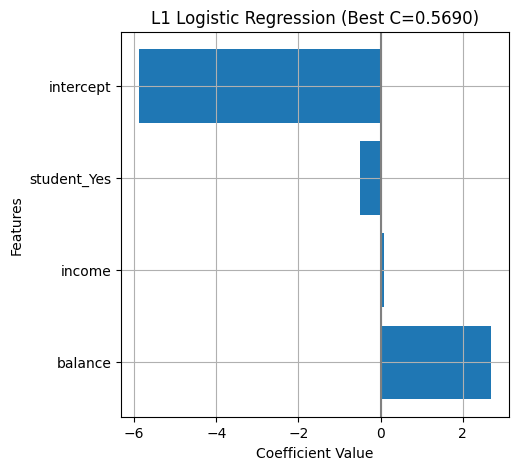

,feature,coef
2,balance,2.694787
3,income,0.074969
1,student_Yes,-0.494251
0,intercept,-5.883171


In [36]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report

log_pipe_l1 = make_pipeline(
    ColumnTransformer(
        [("cat", OneHotEncoder(drop=["No"]), ['student']),
         ("num", StandardScaler(), ['balance', 'income'])],
        verbose_feature_names_out=False
    ),
    LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
)

C_list_l1 = np.logspace(-3, 2, 50)
log_rs_l1 = GridSearchCV(
    log_pipe_l1,
    param_grid={'logisticregression__C': C_list_l1},
    scoring=["f1", "recall", "precision", "accuracy"],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    refit="f1", 
    return_train_score=True
)
log_rs_l1.fit(X_train, y_train)

print("Best C (L1):", log_rs_l1.best_params_)
print("\nTest Classification Report:")
print(classification_report(y_test, log_rs_l1.predict(X_test), target_names=['No Default', 'Default']))

# Plot coefficients
get_coefs(
    log_rs_l1.best_estimator_,
    plot=True,
    figtitle=f"L1 Logistic Regression (Best C={log_rs_l1.best_params_['logisticregression__C']:.4f})"
)


Q10a)

F1-score was chosen, as it balances precision and recall, and is more appropriate than accuracy for highly imbalanced data.

Q10b)

With L1 regularization, all three features ("student", "income", "balance") were included.

Both regularized (F1-score = 0.53) and unregularized (F1-score = 0.528) models have similar performance. L1 regularization does not improve performance, as the dataset is low-dimensional (3 features only).

# Dealing with Imbalanced Data <a id='Imbal'></a>

We have already seen that when dealing with imbalanced data, we need to 
1. Considering a suitable performance metric both for testing and validation.
2. Use a suitable splitting strategy (stratified splitting) both in creating our test and validation sets.

But the majority class can still overwelm the minority class when fitting the model. To investigate, let's use the function  [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html), which reports summary of the precision, recall, F1 score for each class. Note that:
- the recall of the positive class is also known as *sensitivity*; recall of the negative class is *specificity*.
- it also includes the *macro average* (averaging the unweighted mean per label) as well as the weighted average (averaging the support-weighted mean per label). 

In [37]:
# Compute and print the classification report for the model with no penatly
from sklearn.metrics import classification_report

print(classification_report(y_test, 
                            log_pipe.predict(X_test), 
                            target_names = ['No Default','Default']))

              precision    recall  f1-score   support

  No Default       0.98      0.99      0.99       967
     Default       0.70      0.42      0.53        33

    accuracy                           0.97      1000
   macro avg       0.84      0.71      0.76      1000
weighted avg       0.97      0.97      0.97      1000



Notice, how the metrics are much higher for the majority class (individuals who have not deafulted). In this case, we may want to alter the training algorithm or data by:

1. Weighting the classes during training.
2. Resampling the data.

`LogisticRegression` offers the option to include class weights, and for example `class_weight="balanced"` will weight the classes by: $$\frac{N}{2 N_c}$$, where  $N_c$ for $c = 0, 1$ counts the number of observations in each class. Notice how the metrics in classification report change when including this option in the code below. 

In [38]:
log_pipe_balan = make_pipeline(
    ColumnTransformer(
        [("cat", OneHotEncoder(drop=["No"]), ['student']),
         ("num", StandardScaler(), ['balance','income'])],
         verbose_feature_names_out=False
    ),
    LogisticRegression(random_state=42, penalty=None, class_weight='balanced')
).fit(X_train, y_train)

print(classification_report(y_test, 
                            log_pipe_balan.predict(X_test), 
                            target_names = ['No Default','Default']))

              precision    recall  f1-score   support

  No Default       1.00      0.87      0.93       967
     Default       0.19      0.91      0.32        33

    accuracy                           0.87      1000
   macro avg       0.59      0.89      0.62      1000
weighted avg       0.97      0.87      0.91      1000



In the following, the focus is on suitable **resampling** to change the distribution of the classes in our training data.

## Resampling

To alter the distribution of the classes in our training data, there are two main approaches:

- Under-sampling the majority class
- Over-sampling the minority class

We will be using Imbalanced-learn (imported as `imblearn`), an open source, MIT-licensed library relying on scikit-learn that provides tools for dealing with classification with imbalanced classes (see [here](https://imbalanced-learn.org/stable/introduction.html) for an introduction). Let's start by installing the `imblearn` package if necessary.

In [ ]:
# Install the imblearn if necessary 
# !pip install imblearn

In the previous notebooks, we learned about _transformers_, which allow us to __alter the features__ and not the number of observations in our data (i.e. the columns of $\mathbf{X}$). Instead, _resamplers_ provide a preprocessing step in our `Pipeline` to __alter the number of observations__ and not the features (i.e. the rows of $\mathbf{X}$ and $\mathbf{y}$).

__Resamplers__

Resamplers are classes that follow the scikit-learn API and have a sampling functionality through the `.resample()` method. Like all other scikit-learn methods, they have a `.fit()` method which is only applied during pipeline training. This means if we want to create our own resampler from scratch that is compatible with scikit-learn, we just have to make a class that has three methods; `.fit()`,  `.resample()`, and `.fit_resample()`; with the latter just chaining the other two together.

Therefore to resample a dataset, each sampler implements:

```
obj.fit(data, targets)
data_resampled, targets_resampled = obj.resample(data, targets)
```

or simply...

```
data_resampled, targets_resampled = obj.fit_resample(data, targets)
```

**Remember to include your sampler within your model pipeline to prevent data leakage!**


### Under-Sampling

Under-sampling involves removing observations from the majority class to prevent its signal from dominating during training. We will focus on the simplest strategy:

- [`RandomUnderSampler`](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html), which randomly removes observations from the majority class.

For an overview of other under-samplers, see: https://imbalanced-learn.org/stable/under_sampling.html

In [39]:
from imblearn.pipeline import Pipeline as ImPipeline
from imblearn.under_sampling import RandomUnderSampler

# Pipeline with under sampling
log_pipe_us = ImPipeline([
    ("fe",ColumnTransformer(
        [("cat", OneHotEncoder(drop=["No"]), ['student']),
         ("num", StandardScaler(), ['balance','income'])],
         verbose_feature_names_out=False
    )),
   ("sampler", RandomUnderSampler(random_state=42)),
   ("model", LogisticRegression(random_state=42, penalty=None))])

# Fit model     
log_pipe_us.fit(X_train, y_train)

,steps,"[('fe', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 🚩 Exercise 11 (CORE)

Compute and print the classification report and visualize the confusion matrix for the model above with undersampling. How have the results changed?

Classification Report - Under-sampling:
              precision    recall  f1-score   support

  No Default       1.00      0.86      0.93       967
     Default       0.18      0.88      0.30        33

    accuracy                           0.86      1000
   macro avg       0.59      0.87      0.61      1000
weighted avg       0.97      0.86      0.90      1000



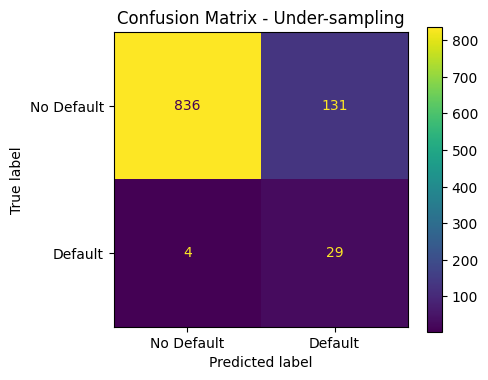

In [40]:
y_pred_us = log_pipe_us.predict(X_test)

print("Classification Report - Under-sampling:")
print(classification_report(y_test, y_pred_us, target_names=['No Default', 'Default']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(
    log_pipe_us, X_test, y_test,
    display_labels=['No Default', 'Default'], ax=ax
)
plt.title('Confusion Matrix - Under-sampling')
plt.tight_layout()
plt.show()

Q11)

Compared to baseline model (no resampling):

- Recall increases significantly from 0.424 to 0.88
- Precision drops significantly from 0.700 to 0.18
- Accuracy drops significantly from 0.975 to 0.86
- F1-score drops from 0.528 to 0.3

Therefore, under-sampling trades accuracy and precision for recall, which may be useful when detecting positives is more important and false positives are tolerable. However, undersampling discards the majority class data, losing useful information.

## Oversampling

Over-sampling involves generating additional observations from the minority class. We will focus on the simplest strategy:

- [`RandomOverSampler`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html), which randomly samples with replacement observations from the minority class.

For an overview of other over-samplers, see: https://imbalanced-learn.org/stable/over_sampling.html

### 🚩 Exercise 12 (CORE)

a. Create a new pipeline for a logisitic regression model with oversampling (by copying and editting the pipeline above).

b. How do the performance metrics compare with over-sampling?

Classification Report - Over-sampling:
              precision    recall  f1-score   support

  No Default       1.00      0.87      0.93       967
     Default       0.19      0.91      0.32        33

    accuracy                           0.87      1000
   macro avg       0.59      0.89      0.62      1000
weighted avg       0.97      0.87      0.91      1000



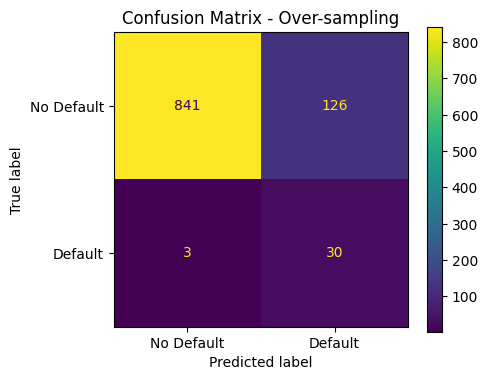

In [41]:
from imblearn.over_sampling import RandomOverSampler

log_pipe_os = ImPipeline([
    ("fe", ColumnTransformer(
        [("cat", OneHotEncoder(drop=["No"]), ['student']),
         ("num", StandardScaler(), ['balance', 'income'])],
        verbose_feature_names_out=False
    )),
    ("sampler", RandomOverSampler(random_state=42)),
    ("model", LogisticRegression(random_state=42, penalty=None))
])

log_pipe_os.fit(X_train, y_train)

# Evaluate
y_pred_os = log_pipe_os.predict(X_test)
print("Classification Report - Over-sampling:")
print(classification_report(y_test, y_pred_os, target_names=['No Default', 'Default']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(
    log_pipe_os, X_test, y_test,
    display_labels=['No Default', 'Default'], ax=ax
)
plt.title('Confusion Matrix - Over-sampling')
plt.tight_layout()
plt.show()

Q12)

Compared to under-sampling, over-sampling performs slightly better across all metrics since it retains all majority class data. While both techniques significantly improve recall, both still suffer from very low precision.

---
# Multi-class Logistic Regression <a id='mclog'></a>

Finally, to gain some experience with multi-class logistic regression, let's now look at the `iris` data set, which we have seen already in lectures.  

This is an example where the response has **3 classes** corresponding to the three types of iris species and $D=4$ features (petal length, petal width, sepal length, sepal width).

Let's start by loading the data and doing some basic EDA.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

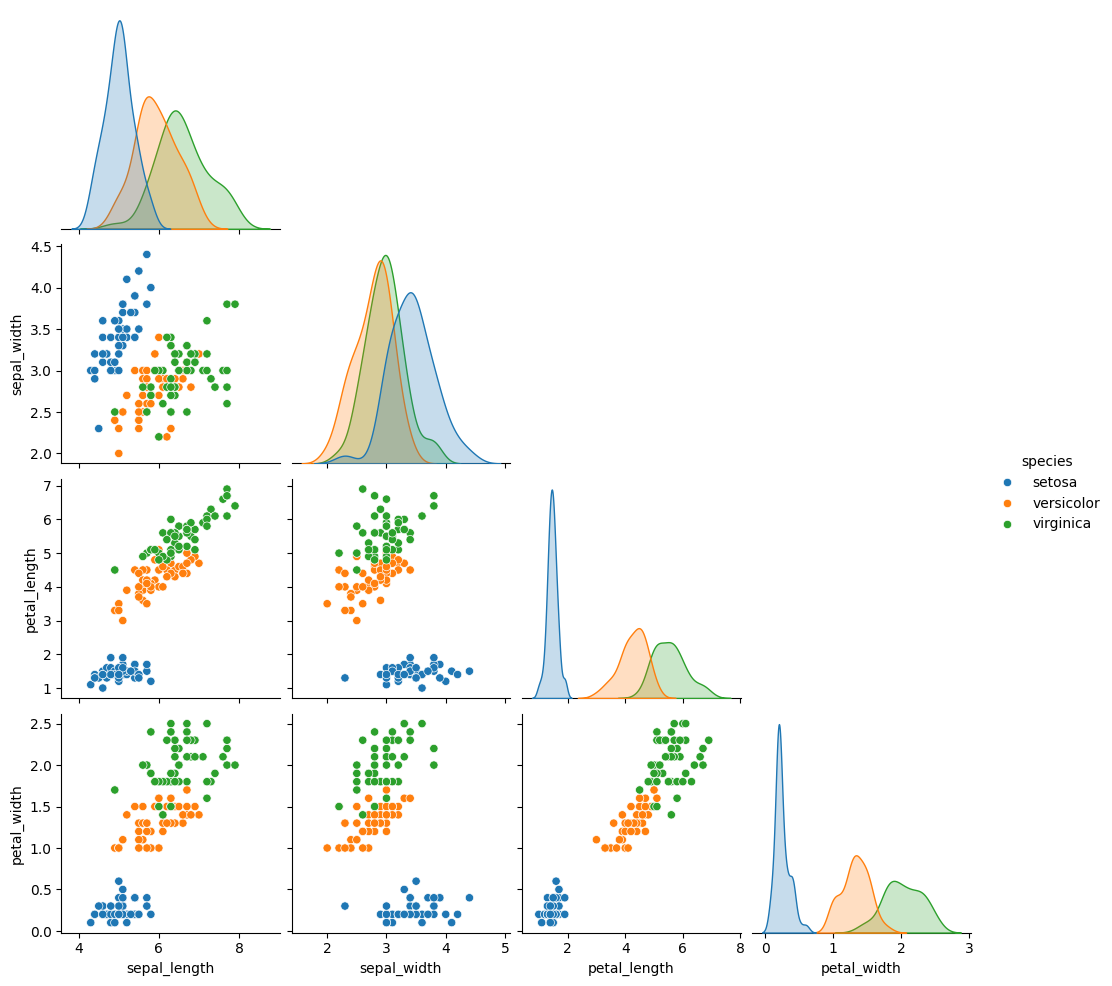

In [46]:
# First load the data 
from sklearn.datasets import load_iris

# Loading data
iris = pd.DataFrame(sns.load_dataset('iris'))

# Print information about the data set
print(iris.info())
print(iris.describe())
print(iris['species'].value_counts())

# Pairplot
sns.pairplot(data = iris, hue = 'species',corner=True)
plt.show()

From the intial EDA, we observe:
- The features have similar, but slightly different scales.
- Visually, the species appear to be fairly well separated.
- The target variable `species` is a string and we will need a label encoding
- The species types are equal distributed, and thus no methods for class imbalance are needed.

Now, let's separate the features and target, encode the target, and split into training and test sets.

In [43]:
# Feature matrix and response vector
X, y = iris.drop(['species'], axis=1), iris['species']

# Encode target
y = LabelEncoder().fit_transform(y)

# Split into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True) 

### 🚩 Exercise 13 (CORE)

We can use the same `LogisticRegression` for the multi-class setting. In this case, it will fit the **multinomial logistic regression** model. Fit a multinomial logisitic regression model and visualize the confusion matrix.

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



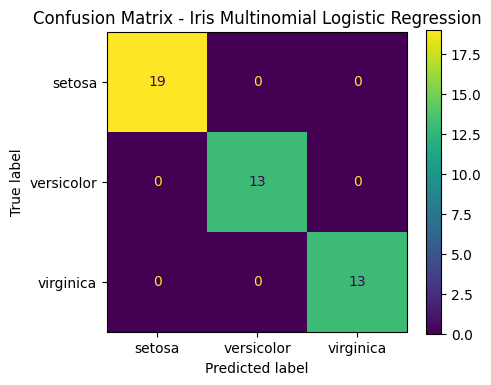

In [47]:
iris_data = load_iris()

log_iris = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, multi_class='multinomial', max_iter=200)
)
log_iris.fit(X_train, y_train)

print("Test Accuracy:", log_iris.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, log_iris.predict(X_test),
                             target_names=iris_data.target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(
    log_iris, X_test, y_test,
    display_labels=iris_data.target_names, ax=ax
)
plt.title('Confusion Matrix - Iris Multinomial Logistic Regression')
plt.tight_layout()
plt.show()

### 🚩 Exercise 14 (EXTRA)

In the multi-class setting, the `.coef_` attribute is a $C \times D$ matrix of the model coefficients. Recall that the log odds of being in class $c$ relative to class $c'$ is:

$$\log \left(\frac{p(y=c \mid \mathbf{x})}{p(y=c' \mid \mathbf{x})} \right) = \log \left(\frac{\exp(\mathbf{w}_c^T\mathbf{x})}{\sum_{l=1}^C\exp(\mathbf{w}_l^T\mathbf{x})} / \frac{\exp(\mathbf{w}_{c'}^T\mathbf{x})}{\sum_{l=1}^C\exp(\mathbf{w}_l^T\mathbf{x})} \right) = \left(\mathbf{w}_{c} - \mathbf{w}_{c'} \right)^T\mathbf{x}$$

For each unique pair of classes, create a barplot to visualize the coefficients of one class relative to another, i.e. $\mathbf{w}_{c} - \mathbf{w}_{c'}$. Which features are most important for distinguishing between classes? Interpret how a unit change in the features affects the odds of being in one class relative to another.

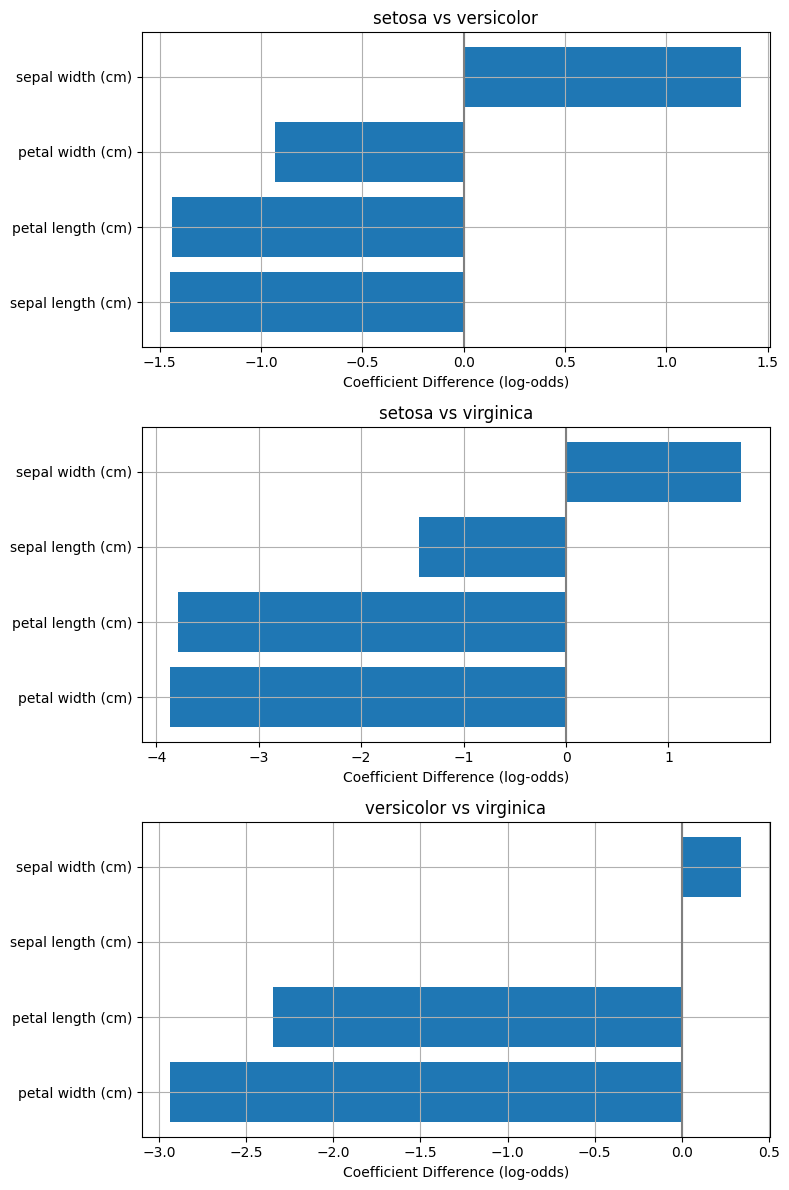

Most discriminative feature per class pair:
  setosa vs versicolor: sepal length (cm) (-1.447)
  setosa vs virginica: petal width (cm) (-3.864)
  versicolor vs virginica: petal width (cm) (-2.935)


In [68]:
import itertools

coef = log_iris[-1].coef_
feature_names_iris = list(iris_data.feature_names)
class_names_iris = list(iris_data.target_names)
class_pairs = list(itertools.combinations(range(3), 2))

fig, axes = plt.subplots(3, 1, figsize=(8, 12))
for k, (c, cprime) in enumerate(class_pairs):
    w_diff = coef[c] - coef[cprime]
    df_coef = pd.DataFrame({'feature': feature_names_iris, 'coef_diff': w_diff}).sort_values('coef_diff')
    axes[k].barh(df_coef['feature'], df_coef['coef_diff'])
    axes[k].axvline(0, color='.5')
    axes[k].set_title(f'{class_names_iris[c]} vs {class_names_iris[cprime]}')
    axes[k].set_xlabel('Coefficient Difference (log-odds)')
    axes[k].grid(True)

plt.tight_layout()
plt.show()

print("Most discriminative feature per class pair:")
for c, cprime in class_pairs:
    w_diff = coef[c] - coef[cprime]
    idx_max = np.argmax(np.abs(w_diff))
    print(f"  {class_names_iris[c]} vs {class_names_iris[cprime]}: {feature_names_iris[idx_max]} ({w_diff[idx_max]:.3f})")



The coefficient difference $(\mathbf{w}_c - \mathbf{w}_{c'})^T\mathbf{x}$ gives the log-odds of being in class $c$ vs class $c'$.

- Setosa vs Versicolor
    - Only "sepal width" is positive. A unit increase in "sepal width" increases the log-odds of being setosa over versicolor by a factor of ~1.4.
    - "Sepal length", "petal width" and "petal length" are negative. A unit increase in these features increases the log-odds of being versicolor over setosa (~0.9, ~1.4, ~1.4 respectively).
    - "Sepal width", "sepal length" and "petal length" seem to be equally-dominant features.
    - Setosa tends to have wider sepals, while versicolor tend to have longer, wider petals and longer sepals.
- Setosa vs Virginica
    - A unit increase in "sepal width" increases the log-odds of being setosa over virginica (~1.3), while a unit increase in "sepal length" increases the log-odds of being virginica over setosa (~1.2).
    - "Petal width" and "petal length" have the strongest effect, where a unit increase in these features strongly increases the log-odds of being virginica over setosa (~3.3-3.4).
    - Setosa tends to have wider sepals, while virginica tend to have longer, wider petals and longer sepals.
- Versicolor vs Virginica
    - "Sepal length" seems to have no effect on the log-odds.
    - "Sepal width" have a relatively small effect on the log-odds, where a unit increase in "sepal width" slightly increases the log-odds of being versicolor over virginica (~0.3).
    - "Petal width" and "petal length" have significantly large effects on the log-odds, where a unit increase in these features greatly increases the log-odds of being virginica over versicolor (~2.9 and ~2.3 respectively). "Petal width" is the most dominant feature.
    - Virginica tends to have longer and wider petals than versicolor.

Conclusion: Petal dimensions (especially "petal width" and "petal length") are the most important features for distinguishing iris species. Sepal measurements are less informative, consistent with the pairplot from EDA where sepal features showed more class overlap.

# Competing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.

Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
# !jupyter nbconvert --to pdf mlp_week06.ipynb 